[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/syaikhipin/kdd26-memdiag/blob/tutorial-rebuild/tutorial/phase1_memory_architectures/05_frameworks.ipynb)

> **Run this notebook in Google Colab** — click the badge above. The setup cell auto-clones the repo.


# Phase 1E - Frameworks (24-27)

**Phase 1E - Frameworks (24-27)** - an independent notebook (runnable standalone in Colab or locally).

Covers: Frameworks (24-27) - production memory libraries.

Attribution: adapted from *Agent Memory Techniques* by Nir Diamant (https://github.com/NirDiamant/Agent_Memory_Techniques), Apache-2.0. Inline demos are original.

## 0. Setup (self-contained - run this first)

In [1]:
# Self-contained setup - works standalone in Google Colab or locally.
import sys, os, subprocess
from pathlib import Path
REPO_URL = "https://github.com/syaikhipin/kdd26-memdiag"
try:
    import google.colab  # noqa
    IN_COLAB = True
except Exception:
    IN_COLAB = False
if IN_COLAB:
    repo = Path("/content/kdd26-memdiag")
    if not repo.exists():
        subprocess.run(["git", "clone", "--depth", "1", "--branch", "tutorial-rebuild", REPO_URL, str(repo)], check=False)
    SOURCE = repo / "source"
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "numpy", "matplotlib", "pyyaml", "openai"], check=False)
else:
    SOURCE = None
    for cand in [Path.cwd(), *Path.cwd().parents]:
        for sub in ("source", "experiment"):
            if (cand / sub / "run.py").exists():
                SOURCE = cand / sub
                break
        if SOURCE:
            break
    if SOURCE is None:
        raise FileNotFoundError("Run from the repo root (or in Colab it auto-clones).")
sys.path.insert(0, str(SOURCE))
os.environ.setdefault("OPENAI_BASE_URL", "https://api.openai.com/v1")
SOURCE_DIR = SOURCE
PROJECT_ROOT = SOURCE.parent
RESULTS_DIR = PROJECT_ROOT / "results"
try: _d = "<repo>/" + str(Path(SOURCE).relative_to(PROJECT_ROOT))
except Exception: _d = "<repo>/source"
print("SOURCE_DIR =", _d, "| found =", True, "| IN_COLAB =", IN_COLAB)

from embedder import TfidfHashEmbedder
from llm_client import LLMConfig, make_client, OfflineLLMClient
from memory_core import MemoryRecord
from providers import build_provider
emb = TfidfHashEmbedder()
try:
    llm = make_client(LLMConfig(backend='openai-compatible' if os.environ.get('OPENAI_API_KEY') else 'offline',
                                base_url=os.environ.get('OPENAI_BASE_URL','https://api.openai.com/v1'),
                                model='gpt-4o'))
except Exception:
    llm = OfflineLLMClient()
print('LLM backend:', llm.backend, '| API key:', bool(os.environ.get('OPENAI_API_KEY')))
TURNS = [
 ("Alice", "Hi, I am Alice. I work as a data scientist at a health-tech startup in Berlin."),
 ("Bob", "I am Bob, an ML engineer in Athens. I prefer PyTorch."),
 ("Alice", "We deploy on Kubernetes and track runs with Weights and Biases."),
 ("Bob", "Our training run failed last night with CUDA OOM at batch 256."),
 ("Alice", "We hit that before. Reducing batch to 64 and enabling gradient checkpointing fixed it."),
 ("Bob", "Our best val_loss was 0.423 with lr=3e-4 and weight_decay=0.01."),
 ("Alice", "I live in Prenzlauer Berg. My favorite coffee shop is on Kollwitzplatz."),
 ("Bob", "Let us sync next Tuesday at 10am CET."),
]
records = [MemoryRecord(f"t{i}", f"{w}: {t}", {"session_id": "s1" if i < 4 else "s2"}) for i, (w, t) in enumerate(TURNS)]
print("setup OK | turns =", len(TURNS))


SOURCE_DIR = <repo>/source | found = True | IN_COLAB = False
LLM backend: offline | API key: False
setup OK | turns = 8


## ⚙️ Set up your LLM at the beginning — base URL · API key · model
On first run this cell **prompts you for three things**: your OpenAI-compatible **base URL**, **API key** (hidden input), and **model**. They are saved to **Google Drive** in Colab (or a local file) so every other notebook and every future session reuses them — you set up **once**. Press **Enter** to keep a default / run offline. To reconfigure later: set `KDD_RECONFIG=1` or delete the saved config file shown below.

In [2]:
# === Set up your LLM at the beginning: base URL, API key, model ===
# First run: you are prompted for the 3 values (API key hidden). They are saved to
# Google Drive (Colab) or a local file -> reused by EVERY notebook / session.
# To re-prompt later: set os.environ['KDD_RECONFIG']='1' before running, or delete the file.
import os, json, getpass
from pathlib import Path

try:
    from google.colab import drive          # one-time auth -> config persists on Drive
    drive.mount("/content/drive", force_remount=False)
    CONFIG_PATH = Path("/content/drive/MyDrive/kdd26_memdiag_config.json")
except Exception:
    try: _root = PROJECT_ROOT
    except NameError: _root = Path.cwd()
    CONFIG_PATH = Path(_root) / "results" / "kdd26_memdiag_config.json"

def load_llm_config():
    return json.loads(CONFIG_PATH.read_text()) if CONFIG_PATH.exists() else {}

def save_llm_config(base_url, api_key, model):
    CONFIG_PATH.parent.mkdir(parents=True, exist_ok=True)
    CONFIG_PATH.write_text(json.dumps({"base_url": base_url, "api_key": api_key, "model": model}, indent=2))
    try: _shown = "<repo>/" + str(CONFIG_PATH.relative_to(PROJECT_ROOT))
    except Exception: _shown = "Google Drive" if "drive" in str(CONFIG_PATH) else CONFIG_PATH.name
    print("saved ->", _shown)

_cfg = load_llm_config()
RECONFIG = os.environ.get("KDD_RECONFIG", "0") == "1"
if (not _cfg) or RECONFIG:
    _d_base  = _cfg.get("base_url") or "https://api.openai.com/v1"   # generic, Colab-executable default
    _d_model = _cfg.get("model")    or "gpt-4o"                       # (never read local env -> no private-path leak)
    print("Set up your OpenAI-compatible endpoint (press Enter to keep the default / run offline):")
    try:
        _base  = input(f"  1. base URL [{_d_base}]: ").strip() or _d_base
        _model = input(f"  2. model    [{_d_model}]: ").strip() or _d_model
        _key   = getpass.getpass("  3. API key (hidden, Enter = none/offline): ").strip() or _cfg.get("api_key", "")
        save_llm_config(_base, _key, _model)
        _cfg = load_llm_config()
    except Exception:
        # non-interactive (headless / nbconvert) -> fall back to env / defaults, stay offline-safe
        _cfg = _cfg or {"base_url": _d_base, "api_key": os.environ.get("OPENAI_API_KEY", ""), "model": _d_model}

OPENAI_BASE_URL = _cfg.get("base_url") or "https://api.openai.com/v1"   # generic default; set yours via the prompt
OPENAI_API_KEY  = _cfg.get("api_key")  or os.environ.get("OPENAI_API_KEY", "")
OPENAI_MODEL    = _cfg.get("model")    or "gpt-4o"
os.environ.update({"OPENAI_BASE_URL": OPENAI_BASE_URL, "OPENAI_MODEL": OPENAI_MODEL})
if OPENAI_API_KEY:
    os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY

try:
    llm = make_client(LLMConfig(backend="openai-compatible" if OPENAI_API_KEY else "offline",
                                 base_url=OPENAI_BASE_URL, model=OPENAI_MODEL))
    _be = llm.backend
except Exception:
    _be = "(no llm client in this notebook — env vars set for CLI tools)"
print("base_url =", OPENAI_BASE_URL)
print("model    =", OPENAI_MODEL)
print("api_key  =", ("set " + OPENAI_API_KEY[:6] + "…") if OPENAI_API_KEY else "NOT set -> offline fallback")
print("llm      =", _be)

base_url = https://api.openai.com/v1
model    = gpt-4o
api_key  = set sk…
llm      = openai-compatible


## Frameworks (24-27) - production memory libraries

## Visualization helpers + framework data  (run once)

In [3]:
import subprocess, sys, math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from collections import Counter

PRIMARY='#1F2937'; ACCENT='#2563EB'; GREEN='#15803D'; AMBER='#B45309'; MUTED='#6B7280'; LIGHT='#F5F5F5'

def _box(ax,x,y,w,h,text,fc=LIGHT,ec=PRIMARY,tc=PRIMARY,fs=10,bold=False):
    ax.add_patch(FancyBboxPatch((x,y),w,h,boxstyle='round,pad=0.02,rounding_size=0.05',fc=fc,ec=ec,lw=1.4))
    ax.text(x+w/2,y+h/2,text,ha='center',va='center',fontsize=fs,color=tc,weight='bold' if bold else 'normal')

def _arrow(ax,x1,y1,x2,y2,color=PRIMARY,lw=1.7):
    ax.add_patch(FancyArrowPatch((x1,y1),(x2,y2),arrowstyle='-|>',mutation_scale=15,color=color,lw=lw))

def _newfig(w=9.8,h=2.8):
    fig,ax=plt.subplots(figsize=(w,h),dpi=120); ax.set_axis_off(); return fig,ax

# capability matrix (1 = supported) for the comparison heatmap
FRAMEWORKS = ['Graphiti', 'Mem0', 'Letta/MemGPT', 'Zep']
CAPS = ['KG / graph', 'Time-aware', 'Self-editing', 'Managed/SDK', 'Entity extraction', 'Multi-hop']
MATRIX = np.array([
    [1,1,0,0,1,1],   # Graphiti
    [0,0,0,1,1,0],   # Mem0
    [0,0,1,1,0,0],   # Letta/MemGPT
    [1,1,0,1,1,0],   # Zep
])
KEYWORDS = {
    'Graphiti':'temporal knowledge graph episode fact time-aware multi-hop entity relationship edge',
    'Mem0':'managed memory add update delete no-change user preference personalization fact fetch',
    'Letta/MemGPT':'self-editing inner monologue main context archival recall memory pressure budget',
    'Zep':'dialog classification entity extraction temporal graph summarize session production scale',
}
# wordcloud is optional (bar-chart fallback if unavailable)
try:
    from wordcloud import WordCloud  # noqa
    HAVE_WC = True
except Exception:
    HAVE_WC = False
    try:
        subprocess.run([sys.executable,'-m','pip','install','-q','wordcloud'], check=False, timeout=180)
        from wordcloud import WordCloud  # noqa
        HAVE_WC = True
    except Exception:
        HAVE_WC = False
print('helpers ready | wordcloud:', HAVE_WC)

helpers ready | wordcloud: True


## Frameworks (24–27) — capability heatmap
Each framework on a different axis of the memory design space. No single framework dominates — pick by your requirement.

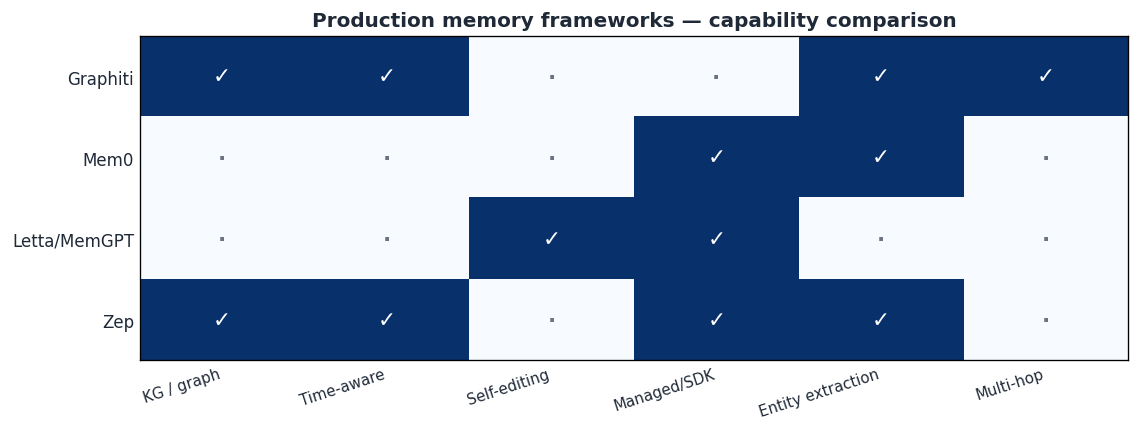

In [4]:
fig,ax=plt.subplots(figsize=(9.6,3.7),dpi=120)
ax.imshow(MATRIX,cmap='Blues',aspect='auto',vmin=0,vmax=1)
ax.set_xticks(range(len(CAPS))); ax.set_xticklabels(CAPS,rotation=18,ha='right',fontsize=9,color=PRIMARY)
ax.set_yticks(range(len(FRAMEWORKS))); ax.set_yticklabels(FRAMEWORKS,fontsize=10,color=PRIMARY)
for i in range(len(FRAMEWORKS)):
    for j in range(len(CAPS)):
        ax.text(j,i,'✓' if MATRIX[i,j] else '·',ha='center',va='center',
                color='white' if MATRIX[i,j] else MUTED,fontsize=13,weight='bold')
ax.set_title('Production memory frameworks — capability comparison',color=PRIMARY,weight='bold')
ax.tick_params(length=0)
fig.tight_layout(); plt.show()

**24 — Graphiti (Zep)** · Time-aware knowledge graphs

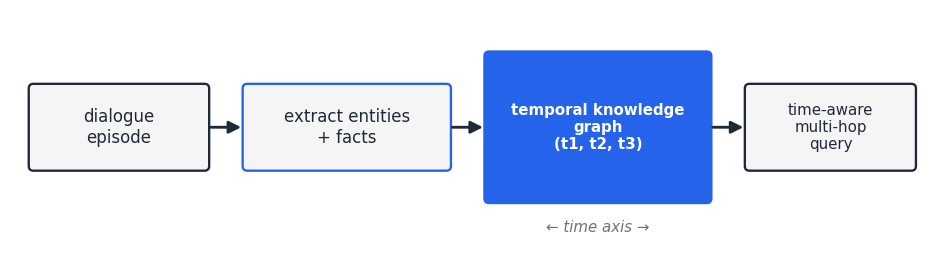

In [5]:
fig,ax=_newfig(9.9,2.6); ax.set_xlim(0,9.9); ax.set_ylim(0,2.6)
_box(ax,0.2,0.9,1.9,0.9,'dialogue\nepisode')
_arrow(ax,2.1,1.35,2.5,1.35)
_box(ax,2.5,0.9,2.2,0.9,'extract entities\n+ facts',fc=LIGHT,ec=ACCENT)
_arrow(ax,4.7,1.35,5.1,1.35)
_box(ax,5.1,0.55,2.4,1.6,'temporal knowledge\ngraph\n(t1, t2, t3)',fc=ACCENT,ec=ACCENT,tc='white',bold=True,fs=9)
_arrow(ax,7.5,1.35,7.9,1.35)
_box(ax,7.9,0.9,1.8,0.9,'time-aware\nmulti-hop\nquery',fs=9)
ax.text(6.3,0.22,'← time axis →',ha='center',color=MUTED,fontsize=9,style='italic')
plt.show()

**25 — Mem0** · Managed memory layer

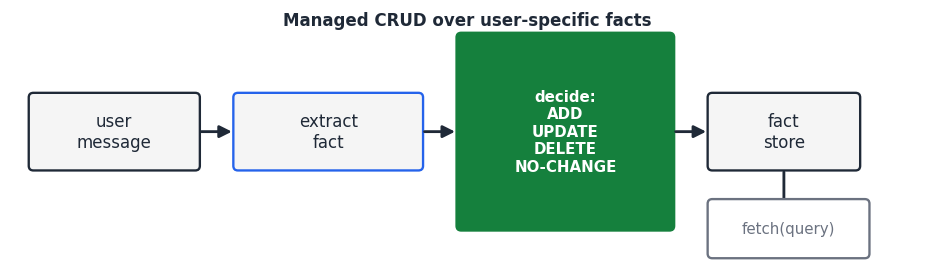

In [6]:
fig,ax=_newfig(9.9,2.7); ax.set_xlim(0,9.9); ax.set_ylim(0,2.7)
_box(ax,0.2,1.0,1.8,0.8,'user\nmessage')
_arrow(ax,2.0,1.4,2.4,1.4)
_box(ax,2.4,1.0,2.0,0.8,'extract\nfact',fc=LIGHT,ec=ACCENT)
_arrow(ax,4.4,1.4,4.8,1.4)
_box(ax,4.8,0.35,2.3,2.1,'decide:\nADD\nUPDATE\nDELETE\nNO-CHANGE',fc=GREEN,ec=GREEN,tc='white',bold=True,fs=9)
_arrow(ax,7.1,1.4,7.5,1.4)
_box(ax,7.5,1.0,1.6,0.8,'fact\nstore')
_arrow(ax,8.3,1.0,8.3,0.45)
_box(ax,7.5,0.05,1.7,0.6,'fetch(query)',fc='white',ec=MUTED,tc=MUTED,fs=9)
ax.text(4.9,2.55,'Managed CRUD over user-specific facts',ha='center',color=PRIMARY,fontsize=10,weight='bold')
plt.show()

**26 — Letta / MemGPT** · Self-editing inner/outer memory

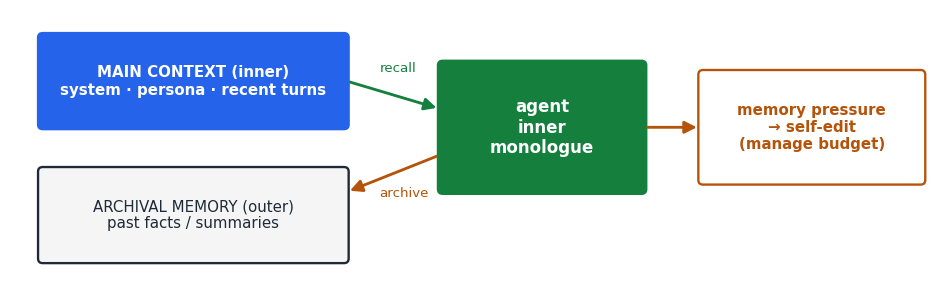

In [7]:
fig,ax=_newfig(9.9,3.0); ax.set_xlim(0,9.9); ax.set_ylim(0,3.0)
_box(ax,0.3,1.75,3.3,1.0,'MAIN CONTEXT (inner)\nsystem · persona · recent turns',fc=ACCENT,ec=ACCENT,tc='white',fs=9,bold=True)
_box(ax,0.3,0.3,3.3,1.0,'ARCHIVAL MEMORY (outer)\npast facts / summaries',fc=LIGHT,fs=9)
_box(ax,4.6,1.05,2.2,1.4,'agent\ninner\nmonologue',fc=GREEN,ec=GREEN,tc='white',bold=True)
_arrow(ax,3.6,2.25,4.6,1.95,color=GREEN); ax.text(3.95,2.35,'recall',color=GREEN,fontsize=8)
_arrow(ax,4.6,1.45,3.6,1.05,color=AMBER); ax.text(3.95,1.0,'archive',color=AMBER,fontsize=8)
_box(ax,7.4,1.15,2.4,1.2,'memory pressure\n→ self-edit\n(manage budget)',fc='white',ec=AMBER,tc=AMBER,fs=9,bold=True)
_arrow(ax,6.8,1.75,7.4,1.75,color=AMBER)
plt.show()

**27 — Zep** · Classification + temporal graphs

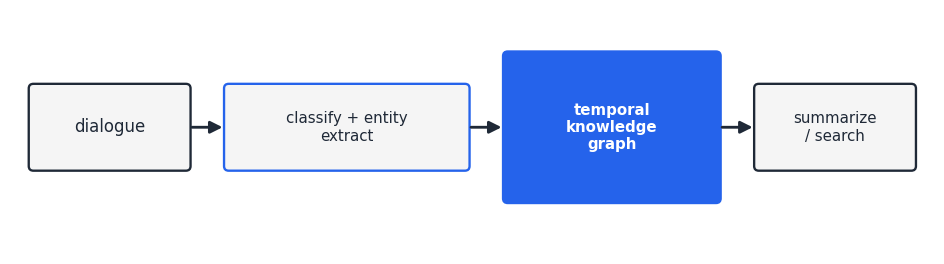

In [8]:
fig,ax=_newfig(9.9,2.6); ax.set_xlim(0,9.9); ax.set_ylim(0,2.6)
_box(ax,0.2,0.9,1.7,0.9,'dialogue')
_arrow(ax,1.9,1.35,2.3,1.35)
_box(ax,2.3,0.9,2.6,0.9,'classify + entity\nextract',fc=LIGHT,ec=ACCENT,fs=9)
_arrow(ax,4.9,1.35,5.3,1.35)
_box(ax,5.3,0.55,2.3,1.6,'temporal\nknowledge\ngraph',fc=ACCENT,ec=ACCENT,tc='white',bold=True,fs=9)
_arrow(ax,7.6,1.35,8.0,1.35)
_box(ax,8.0,0.9,1.7,0.9,'summarize\n/ search',fs=9)
plt.show()

## Framework keyword clouds
If `wordcloud` is installed (auto-installed above) you get clouds; otherwise a keyword-frequency bar chart renders so a figure always shows.

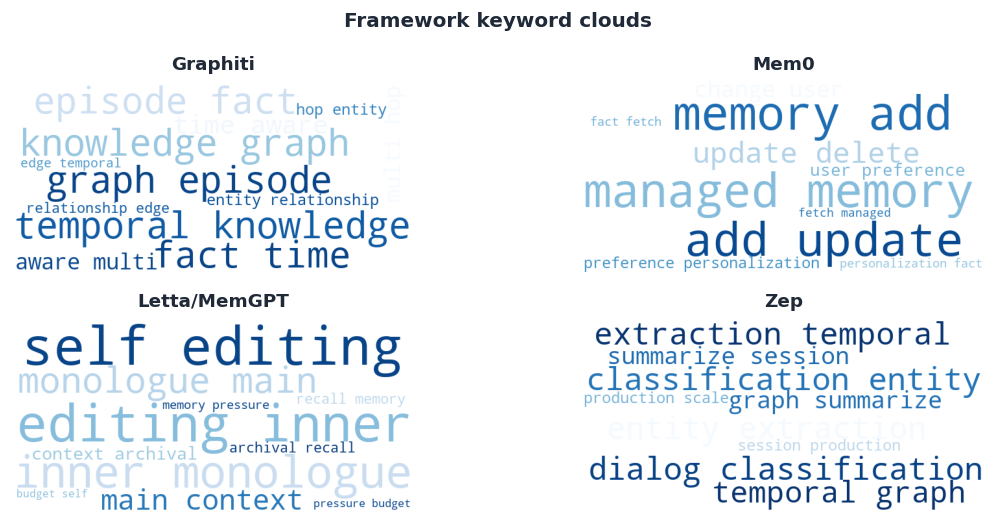

In [9]:
n=len(FRAMEWORKS); cols=2; rows=math.ceil(n/cols)
fig,axes=plt.subplots(rows,cols,figsize=(10,4.4),dpi=120)
for k,fw in enumerate(FRAMEWORKS):
    ax = axes[k//cols][k%cols] if rows>1 else axes[k]
    words = KEYWORDS[fw].split()
    if HAVE_WC:
        wc = WordCloud(width=620,height=300,background_color='white',colormap='Blues').generate(' '.join(words*7))
        ax.imshow(wc); ax.set_axis_off()
    else:
        c=Counter(words); top=c.most_common(8)
        ax.bar([w for w,_ in top],[v for _,v in top],color=ACCENT)
        ax.spines[['top','right']].set_visible(False); ax.tick_params(labelsize=8)
    ax.set_title(fw,fontsize=11,color=PRIMARY,weight='bold')
for k in range(n, rows*cols):
    (axes[k//cols][k%cols] if rows>1 else axes[k]).set_axis_off()
fig.suptitle('Framework keyword clouds' if HAVE_WC else "Framework keyword frequency (pip install wordcloud for clouds)",
             color=PRIMARY,weight='bold')
fig.tight_layout(); plt.show()